In [23]:

from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
tf.config.list_physical_devices('GPU')
df = pd.read_csv('/content/drive/MyDrive/archive(2)/usa_rain_prediction_dataset_2024_2025.csv')
df.head()



,Date,Location,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,2024-01-01,New York,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,2024-01-02,New York,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,2024-01-03,New York,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,2024-01-04,New York,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,2024-01-05,New York,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


<Figure size 500x500 with 0 Axes>

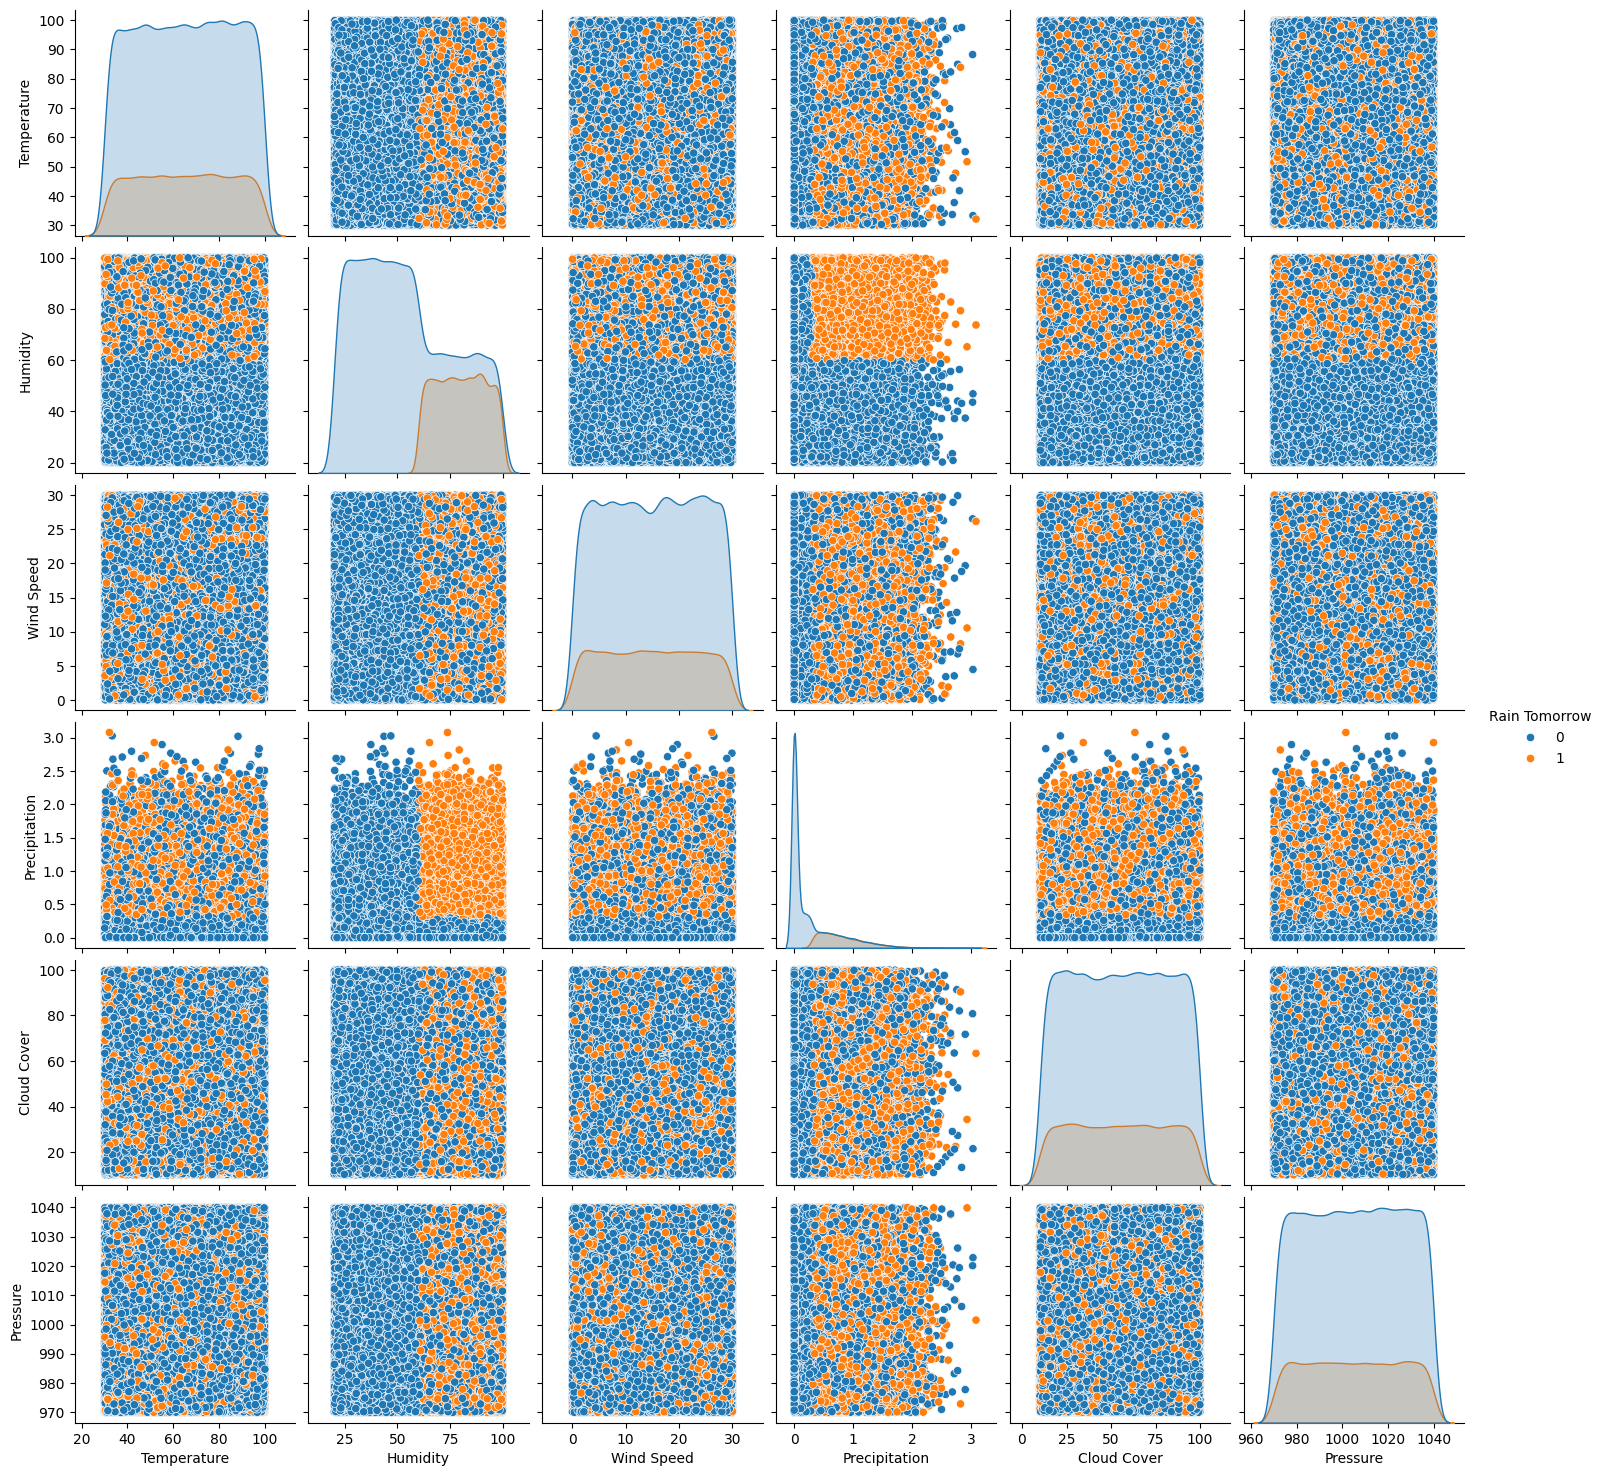

In [9]:
plt.figure(figsize=(5 ,5))
sns.pairplot(df , hue = 'Rain Tomorrow')
plt.show()

In [15]:
df.drop(columns=['Date' , 'Location'] , inplace=True)
df.head()


,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure,Rain Tomorrow
0,87.524795,75.655455,28.379506,0.000000,69.617966,1026.030278,0
1,83.259325,28.712617,12.436433,0.526995,41.606048,995.962065,0
2,80.943050,64.740043,14.184831,0.916884,77.364763,980.796739,1
3,78.097552,59.738984,19.444029,0.094134,52.541196,979.012163,0
4,37.059963,34.766784,3.689661,1.361272,85.584000,1031.790859,0


In [16]:
x_old = df.iloc[ : , : -1]
y = df['Rain Tomorrow']




In [17]:
scaler = MinMaxScaler()
x = scaler.fit_transform(x_old)
x = pd.DataFrame(x , columns=x_old.columns)
x

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Pressure
0,0.821811,0.695701,0.946013,0.000000,0.662426,0.800433
1,0.760873,0.108906,0.414547,0.171208,0.351176,0.370880
2,0.727782,0.559256,0.472831,0.297874,0.748504,0.154229
3,0.687130,0.496742,0.648147,0.030582,0.472680,0.128734
4,0.100851,0.184584,0.122972,0.442246,0.839830,0.882728
...,...,...,...,...,...,...
73095,0.151631,0.563748,0.959308,0.000000,0.490762,0.101185
73096,0.323457,0.132630,0.409429,0.282968,0.134083,0.151299
73097,0.378473,0.959264,0.096474,0.387239,0.470401,0.663843
73098,0.510713,0.548755,0.821103,0.157052,0.742065,0.891375


In [18]:
X_train , X_test , y_train ,y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [19]:
model.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7803 - loss: 0.4880 - val_accuracy: 0.7777 - val_loss: 0.4416
Epoch 2/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7802 - loss: 0.4084 - val_accuracy: 0.7777 - val_loss: 0.3790
Epoch 3/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8103 - loss: 0.3530 - val_accuracy: 0.8526 - val_loss: 0.3275
Epoch 4/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8770 - loss: 0.3071 - val_accuracy: 0.8886 - val_loss: 0.2851
Epoch 5/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9008 - loss: 0.2706 - val_accuracy: 0.9053 - val_loss: 0.2526
Epoch 6/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9114 - loss: 0.2430 - val_accuracy: 0.9191 - val_loss: 0.2279
Epoch 7/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9186 - loss: 0.2219 - val_accuracy: 0.9209 - val_loss: 0.2092
Epoch 8/10
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9259 - loss: 0.2041 -

In [26]:
# Temperature = float(input('Enter current temperature: '))
# Humidity = float(input('Enter current humidity: '))
# Wind_speed = float(input('Enter current wind speed: '))
# Precipitation = float(input('Enter current precipitation: '))
# Cloud_cover = float(input('Enter current cloud cover: '))
# Pressure = float(input('Enter current pressure: '))
# Demo DATA
user_input = pd.DataFrame(
    [[30, 70, 15, 12, 40, 1012]],
    columns=x_old.columns
)

user_scaled = scaler.transform(user_input)

prediction = model.predict(user_scaled)

if prediction[0][0] > 0.5:
    print("Rain Tomorrow: YES 🌧️")
else:
    print("Rain Tomorrow: NO ☀️")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Rain Tomorrow: NO ☀️


In [21]:
loss , accuracy = model.evaluate(X_test , y_test)

loss , accuracy = model.evaluate(X_train , y_train)

572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9456 - loss: 0.1591
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9444 - loss: 0.1619


In [24]:


y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

print(classification_report(y_test, y_pred))

572/572 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     14213
           1       0.94      0.81      0.87      4062

    accuracy                           0.95     18275
   macro avg       0.94      0.90      0.92     18275
weighted avg       0.95      0.95      0.94     18275



In [25]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
[[14010   203]
 [  792  3270]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     14213
           1       0.94      0.81      0.87      4062

    accuracy                           0.95     18275
   macro avg       0.94      0.90      0.92     18275
weighted avg       0.95      0.95      0.94     18275



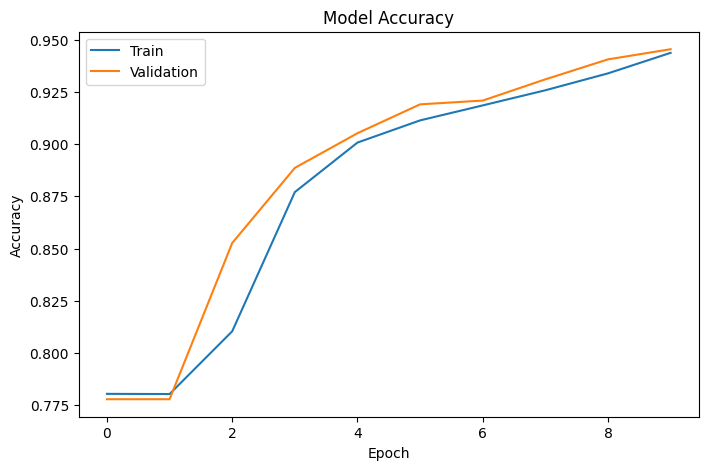

In [28]:

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [30]:
model.save('/content/drive/MyDrive/rain_prediction_model.keras')
import joblib

joblib.dump(scaler, '/content/drive/MyDrive/scaler.pkl')

['/content/drive/MyDrive/scaler.pkl']